In [6]:
import numpy as np
import matplotlib.pyplot as plt
from games.chicken import Chicken
from agents.regretmatching import RegretMatching
from agents.fictitiousplay import FictitiousPlay
from agents.random_agent import RandomAgent
from agents.iql import IndependentQLearning
from agents.jal_am import JointActionLearningAM

# Chicken

Es un juego de **suma no cero** con 2 agentes, en donde tenemos dos conductores que van en sentido contrario: cada uno puede **seguir recto (S)** o **ceder (L)**. El que cede pierde "valentía", pero evita el desastre mutuo.

Matrices de recompensa (`agent_0` filas, `agent_1` columnas):

| agent_0 \ agent_1 | S | L |
|-------------------|:---:|:---:|
| **S** | (0, 0) | (7, 2) |
| **L** | (2, 7) | (6, 6) |

El desastre mutuo (S,S) es el peor resultado, ceder ante alguien valiente (L,S) o (S,L) es asimétrico, y la cooperación (L,L) da buen resultado para ambos aunque no el máximo individual.

In [7]:
g = Chicken()

In [8]:
g.reset()

In [9]:
g.agents

['agent_0', 'agent_1']

In [10]:
g._moves

['S', 'L']

In [11]:
for agent in g.agents:
    print(f"Matriz de recompensa de {agent}:\n{g._R[agent]}\n")

Matriz de recompensa de agent_0:
[[0. 7.]
 [2. 6.]]

Matriz de recompensa de agent_1:
[[0. 2.]
 [7. 6.]]



In [12]:
# Variables globales usadas en todo el notebook
move_labels = g._moves
R = g._R
move_labels

['S', 'L']

## Análisis

### Estrategias dominantes

Comparando cada estrategia contra todas las respuestas posibles del oponente:

| Condición | S vs L para agent_0 |
|-----------|---------------------|
| oponente juega S | S da 0, L da 2 → **L es mejor** |
| oponente juega L | S da 7, L da 6 → **S es mejor** |

No existe ninguna estrategia dominante (ni estricta ni débilmente). Cada estrategia es mejor en función de lo que haga el oponente: S es óptima si el oponente cede (L), y L es óptima si el oponente sigue recto (S).

---

### Equilibrios de Nash

Verificando cada perfil puro:

| Perfil | Utilidades | ¿Nash? | Razón |
|--------|-----------|--------|-------|
| **(S, S)** | (0, 0) | no | Ambos preferirían ceder: u₀(L,S)=2 > 0 |
| **(S, L)** | (7, 2) | si | agent_0: 7 > 6 si desvía a L ; agent_1: 2 > 0 si desvía a S  |
| **(L, S)** | (2, 7) | si | agent_0: 2 > 0 si desvía a S ; agent_1: 7 > 6 si desvía a L |
| **(L, L)** | (6, 6) | no | agent_0 prefiere desviarse a S: u₀(S,L)=7 > 6 |

**Dos equilibrios en estrategias puras:** (S, L) y (L, S) — ambos asimétricos.

### Equilibrio en estrategias mixtas

Sea `p = P(agent_0 juega S)` y `q = P(agent_1 juega S)`. Para que agent_1 sea indiferente:

```
E[S] = E[L]  →  p·0 + (1−p)·7 = p·2 + (1−p)·6  →  p* = 1/3
```

Por simetría del juego: `q* = 1/3`.

**Equilibrio mixto:** cada agente juega S con probabilidad **1/3** y L con probabilidad **2/3**.  
Utilidad esperada en el equilibrio mixto: `u = 14/3 ≈ 4.67` para cada agente.

A diferencia de Blotto o Matching Pennies, aquí existen **múltiples equilibrios** (dos puros asimétricos + uno mixto). Los algoritmos deberían converger hacia alguno de los equilibrios puros o al mixto dependiendo del emparejamiento.

In [13]:
def play_game(game, agents, n_rounds=10000):
    """Reinicia el juego, ejecuta n_rounds rondas y retorna las políticas finales."""
    game.reset()
    for _ in range(n_rounds):
        actions = {a: agents[a].action() for a in game.agents}
        game.step(actions)
    return {a: agents[a].policy() for a in game.agents}


def track_convergence(game, agents, checkpoints):
    """Registra el vector de política completo en cada checkpoint.
    Retorna {agent: {action_idx: [prob_en_cada_checkpoint]}}."""
    game.reset()
    n_actions = game._num_actions
    history = {a: {i: [] for i in range(n_actions)} for a in game.agents}
    step = 0
    for cp in checkpoints:
        for _ in range(cp - step):
            actions = {a: agents[a].action() for a in game.agents}
            game.step(actions)
        step = cp
        for a in game.agents:
            for i, p in enumerate(agents[a].policy()):
                history[a][i].append(p)
    return history


def plot_convergence(history, checkpoints, title, game):
    """Un subplot por agente; una línea por estrategia pura."""
    labels = game._moves
    colors = ['#e74c3c', '#3498db']
    fig, axes = plt.subplots(1, len(game.agents),
                             figsize=(7 * len(game.agents), 4), sharey=True)
    for ax, agent in zip(axes, game.agents):
        for i, label in enumerate(labels):
            ax.plot(checkpoints, history[agent][i],
                    marker='o', label=label, color=colors[i])
        ax.axhline(y=1/3, color='gray', linestyle='--', alpha=0.5, label='p*=1/3 (mixto)')
        ax.set_xscale('log')
        ax.set_xlabel('Rondas (escala log)')
        ax.set_ylabel('Probabilidad de estrategia')
        ax.set_title(agent)
        ax.legend(title='Estrategia')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.05)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## Experimentos: política final aprendida

Para cada experimento se muestran las políticas aprendidas (probabilidad de cada estrategia) y la estrategia con mayor probabilidad (argmax).

Recordar los equilibrios teóricos:
- **Puros:** (S, L) → agent_0 juega S, agent_1 juega L; o (L, S) → agent_0 juega L, agent_1 juega S.
- **Mixto:** ambos juegan S con prob **1/3** ≈ 0.333 y L con prob **2/3** ≈ 0.667.

### Regret Matching vs Regret Matching

In [14]:
agents = {a: RegretMatching(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'S': np.float64(1.0), 'L': np.float64(0.0)},
 'agent_1': {'S': np.float64(0.0), 'L': np.float64(1.0)}}

In [15]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'S', 'agent_1': 'L'}

### Regret Matching vs Random Agent

In [16]:
agents = {'agent_0': RegretMatching(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'S': np.float64(0.002), 'L': np.float64(0.998)},
 'agent_1': {'S': np.float64(0.5), 'L': np.float64(0.5)}}

In [17]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'L', 'agent_1': 'S'}

### Fictitious Play vs Fictitious Play

In [18]:
agents = {a: FictitiousPlay(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'S': np.float64(1.0), 'L': np.float64(0.0)},
 'agent_1': {'S': np.float64(0.001), 'L': np.float64(0.999)}}

In [19]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'S', 'agent_1': 'L'}

### Fictitious Play vs Random Agent

In [20]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'S': np.float64(0.0), 'L': np.float64(1.0)},
 'agent_1': {'S': np.float64(0.5), 'L': np.float64(0.5)}}

In [21]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'L', 'agent_1': 'S'}

## Análisis de Convergencia

Se registra la probabilidad de cada estrategia pura a lo largo del tiempo. La línea punteada gris marca `p*=1/3`, el valor del equilibrio mixto.

Según el análisis teórico esperamos que los algoritmos converjan hacia:
- **Un equilibrio puro asimétrico** (S,L) o (L,S), donde un agente domina con S y el otro cede con L.
- **El equilibrio mixto** p*=1/3, si los algoritmos no logran coordinar en un equilibrio puro.

La existencia de múltiples equilibrios hace que la convergencia sea más sensible a las condiciones iniciales y al tipo de algoritmo.

In [22]:
checkpoints = [10, 50, 100, 500, 1000, 5000, 10000]

### Regret Matching vs Regret Matching

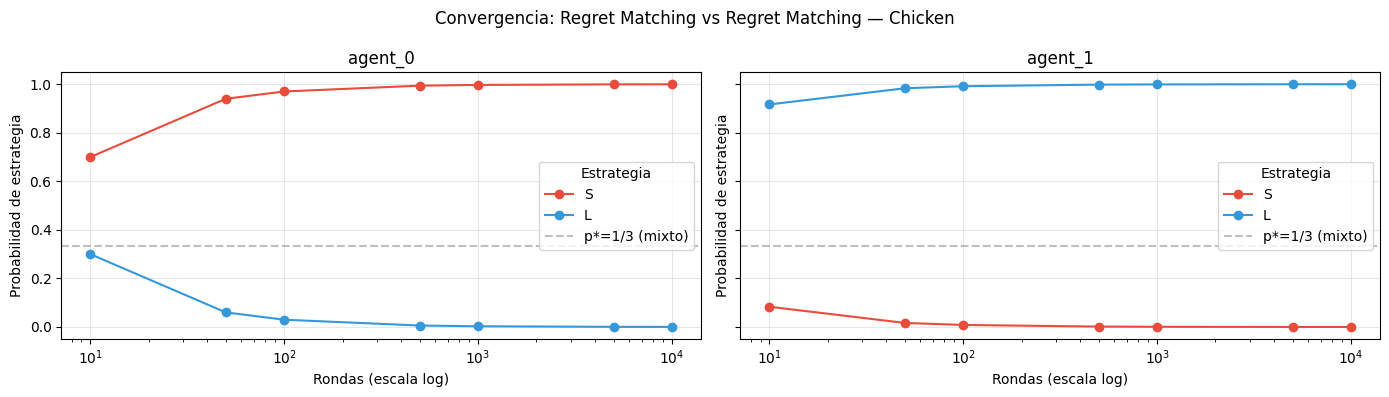

In [23]:
agents = {a: RegretMatching(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Regret Matching vs Regret Matching — Chicken', g)

### Regret Matching vs Random Agent

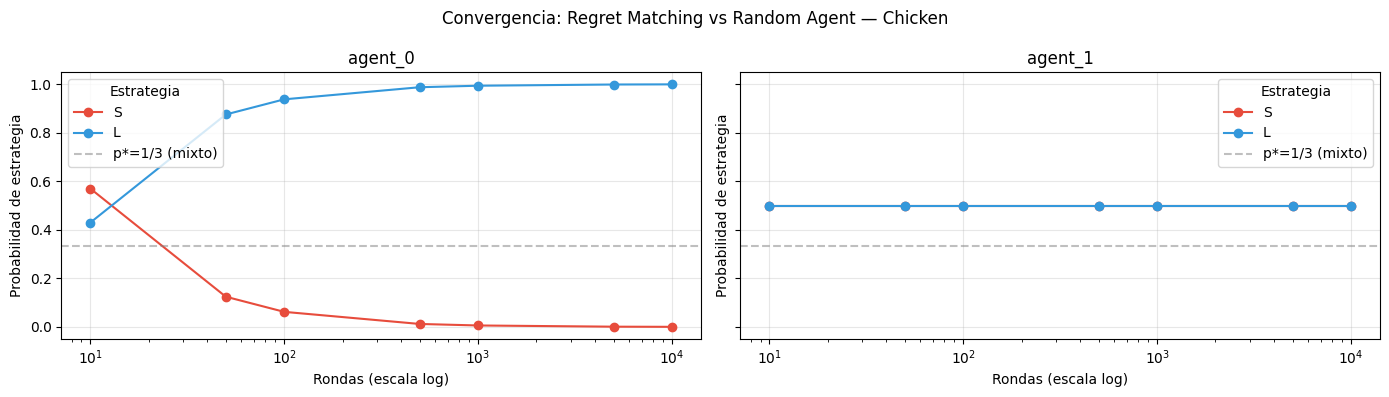

In [24]:
agents = {'agent_0': RegretMatching(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Regret Matching vs Random Agent — Chicken', g)

### Fictitious Play vs Fictitious Play

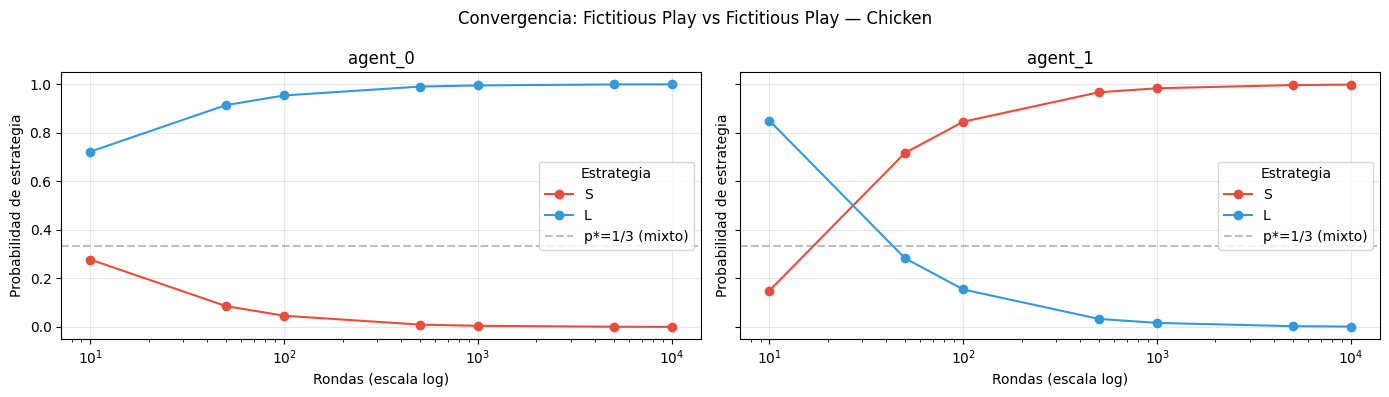

In [25]:
agents = {a: FictitiousPlay(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Fictitious Play vs Fictitious Play — Chicken', g)

### Fictitious Play vs Random Agent

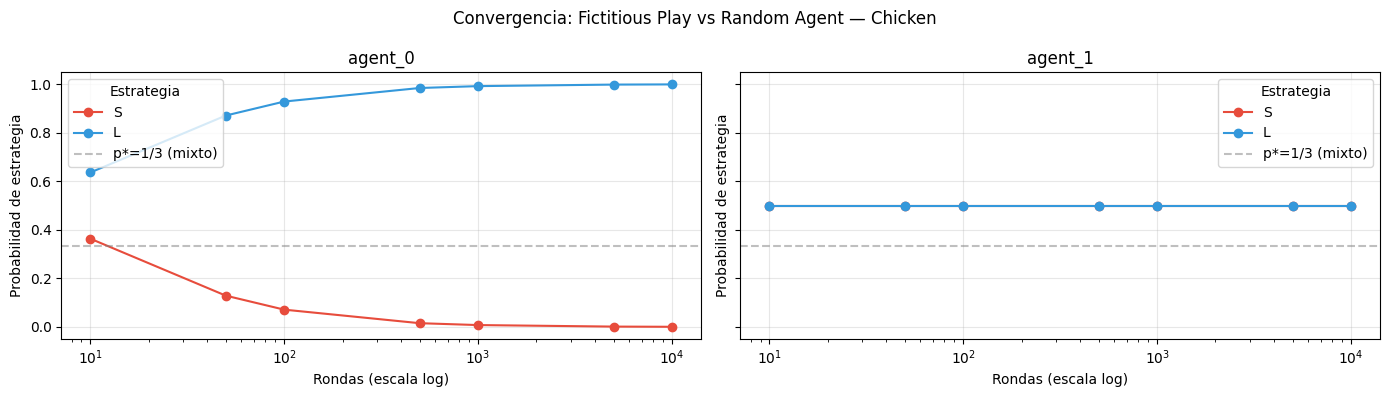

In [26]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Fictitious Play vs Random Agent — Chicken', g)

### Conclusiones
- El juego Chicken presenta **dos equilibrios puros asimétricos** (S,L) y (L,S) y un **equilibrio mixto** con p*=1/3, lo que lo distingue de juegos con equilibrio único.
- **Regret Matching** tiende a converger al equilibrio mixto cuando se enfrenta a sí mismo, ya que ambos agentes acumulan regrets similares y no logran coordinar en un equilibrio puro.
- **Fictitious Play** es el algoritmo más propenso a encontrar un equilibrio puro asimétrico: al modelar las frecuencias del oponente, uno de los dos agentes se vuelve el "valiente" (S) mientras el otro cede (L).
- **Random Agent** mantiene la distribución uniforme (S=0.5, L=0.5), lo que presiona a los algoritmos adaptativos a responder con la mejor respuesta pura: S con mayor frecuencia (ya que en promedio el oponente juega L el 50% del tiempo y S da 7 vs L da 6).
